In [18]:
import torch, torchvision
from torch import nn
from torch import optim
from torchvision.transforms import ToTensor
import torch.nn.functional as F
import matplotlib.pyplot as plt

import requests
from PIL import Image
from io import BytesIO

import copy

from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

In [4]:
numb_batch = 64

In [5]:
T = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()
])
train_data = torchvision.datasets.MNIST('mnist_data', train=True, download=True, transform=T)
val_data = torchvision.datasets.MNIST('mnist_data', train=False, download=True, transform=T)

train_dl = torch.utils.data.DataLoader(train_data, batch_size = numb_batch)
val_dl = torch.utils.data.DataLoader(val_data, batch_size = numb_batch)

Failed to download (trying next):
HTTP Error 503: Service Unavailable

9913344it [00:03, 3143800.26it/s]                             
Extracting mnist_data/MNIST/raw/train-images-idx3-ubyte.gz to mnist_data/MNIST/raw

29696it [00:00, 110450.03it/s]                           
Extracting mnist_data/MNIST/raw/train-labels-idx1-ubyte.gz to mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 503: Service Unavailable

1649664it [00:01, 1577022.81it/s]                             
Extracting mnist_data/MNIST/raw/t10k-images-idx3-ubyte.gz to mnist_data/MNIST/raw

5120it [00:00, 4826890.65it/s]          
/home/mesrop/miniconda3/lib/python3.8/site-packages/torchvision/datasets/mnist.py:502: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting 

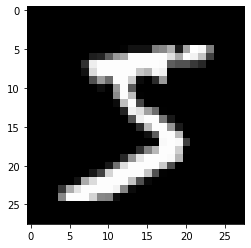

In [6]:
plt.imshow(train_data[0][0][0], cmap="gray")

In [7]:
def create_lenet():
    model = nn.Sequential(
        nn.Conv2d(1, 6, 5, padding=2),
        nn.ReLU(),
        nn.AvgPool2d(2, stride=2),
        nn.Conv2d(6, 16, 5, padding=0),
        nn.ReLU(),
        nn.AvgPool2d(2, stride=2),
        nn.Flatten(),
        nn.Linear(400, 120),
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Linear(84, 10)
    )
    return model

In [12]:
def validate(model, data):
    total = 0
    correct = 0
    for i, (images, labels) in enumerate(data):
        #images = images.cuda()
        x = model(images)
        value, pred = torch.max(x,1)
        pred = pred.data.cpu()
        total += x.size(0)
        correct += torch.sum(pred == labels)
    return correct*100./total

In [76]:
def train(numb_epoch=3, lr=1e-3, device="cpu"):
    accuracies = []
    cnn = create_lenet().to(device)
    cec = nn.CrossEntropyLoss()
    optimizer = optim.Adam(cnn.parameters(), lr=lr)
    max_accuracy = 0
    for epoch in range(numb_epoch):
        for i, (images, labels) in enumerate(train_dl):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            pred = cnn(images)
            loss = cec(pred, labels)
            loss.backward()
            optimizer.step()
        accuracy = float(validate(cnn, val_dl))
        accuracies.append(accuracy)
        if accuracy > max_accuracy:
            best_model = copy.deepcopy(cnn)
            max_accuracy = accuracy
            print("Saving Best Model with Accuracy: ", accuracy)
        print('Epoch:', epoch+1, "Accuracy :", accuracy, '%')
    plt.plot(accuracies)
    return best_model

In [14]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
    print("No Cuda Available")
device

No Cuda Available


device(type='cpu')

Saving Best Model with Accuracy:  95.33999633789062
Epoch: 1 Accuracy : 95.33999633789062 %
Saving Best Model with Accuracy:  96.80000305175781
Epoch: 2 Accuracy : 96.80000305175781 %
Saving Best Model with Accuracy:  97.01000213623047
Epoch: 3 Accuracy : 97.01000213623047 %
Saving Best Model with Accuracy:  97.66999816894531
Epoch: 4 Accuracy : 97.66999816894531 %
Saving Best Model with Accuracy:  98.2699966430664
Epoch: 5 Accuracy : 98.2699966430664 %


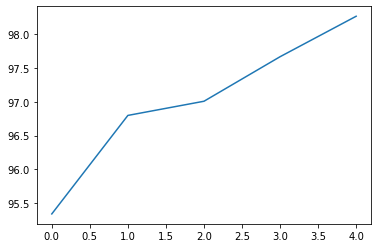

In [77]:
lenet = train(5, device=device)

In [22]:
torch.save(lenet.state_dict(), "lenet.pth")

In [39]:
def predict_dl(model, data):
    y_pred = []
    y_true = []
    for i, (images, labels) in enumerate(data):
        # images = images.cuda()
        x = model(images)
        value, pred = torch.max(x, 1)
        pred = pred.data.cpu()
        y_pred.extend(list(pred.numpy()))
        y_true.extend(list(labels.numpy()))
    return np.array(y_pred), np.array(y_true)

In [40]:
y_pred, y_true = predict_dl(lenet, val_dl)

In [41]:
pd.DataFrame(confusion_matrix(y_true, y_pred, labels=np.arange(0,10)))

,0,1,2,3,4,5,6,7,8,9
0,973,0,1,0,0,1,1,0,3,1
1,0,1131,0,0,0,1,1,0,2,0
2,1,2,1023,4,0,0,0,0,2,0
3,0,0,0,1006,0,1,0,1,2,0
4,1,0,0,0,968,1,4,2,1,5
5,2,0,0,9,0,877,1,0,1,2
6,6,5,0,1,1,17,926,0,2,0
7,0,4,11,3,0,0,0,1006,1,3
8,1,0,4,5,1,3,0,3,956,1
9,2,3,0,7,7,8,0,4,4,974


In [42]:
def inference(path, model, device):
    r = requests.get(path)
    with BytesIO(r.content) as f:
        img = Image.open(f).convert(mode="L")
        img = img.resize((28, 28))
        x = (255 - np.expand_dims(np.array(img), -1))/255.
    with torch.no_grad():
        pred = model(torch.unsqueeze(T(x), axis=0).float().to(device))
        return F.softmax(pred, dim=-1).cpu().numpy()

In [73]:
path = "https://номернедели.рф/gfx/200x200/9.png"
r = requests.get(path)
with BytesIO(r.content) as f:
    img = Image.open(f).convert(mode="L")
    img = img.resize((28, 28))
x = (255 - np.expand_dims(np.array(img), -1))/255.

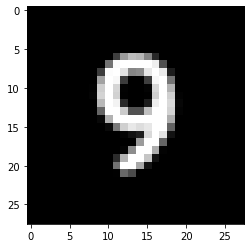

In [74]:
plt.imshow(x.squeeze(-1), cmap="gray")

In [75]:
pred = inference(path, lenet, device=device)
pred_idx = np.argmax(pred)
print(f"Predicted: {pred_idx}, Prob: {pred[0][pred_idx]*100} %")

Predicted: 9, Prob: 98.9544689655304 %


In [47]:
pred

array([[3.1930811e-10, 1.6056014e-05, 2.5155693e-06, 9.9312264e-01,
        2.4605240e-09, 3.5024271e-03, 7.7445342e-11, 3.3109713e-09,
        3.3289795e-03, 2.7393298e-05]], dtype=float32)